# Numeric interferometer precompute comparison

**What you'll learn:**
- How to set up a numeric interferometer using `NumericBraggInterferometer`
- How to plot interferometer arm trajectories from the numeric tree
- How to define beamsplitter and free-evolution functions using `propagate`
- How to simulate an atom cloud and compute interferometer output ellipses
- How to sweep detuning and compute output port populations

In [1]:
import numpy as np
from mwave.numeric import NumericBraggInterferometer
from mwave.integrate import make_kvec, make_phi, propagate, omega_fnc_gaussian, multi_omega_fnc, phase_fnc_constant, score_backends
from mwave.utils.cloud import cloud_init
import numpy as np
from numba import jit, float64

# Set interferometer parameters
omega_r_conversion = 2066*2*np.pi
nbragg = 4
T = 4.5e-3*omega_r_conversion
Tp = 8e-3*omega_r_conversion
    
# Initialize kvec and tree
ifr = NumericBraggInterferometer(-2*nbragg, 4*nbragg, distance=0) # Should pass in wavefunction initialization functions

ifr.split(nbragg) # Should pass in the relevant function here as well! Function will inspect input function arguments to ensure correct number and naming
ifr.propagate(T)
ifr.split(nbragg)
ifr.propagate(Tp)
ifr.split([3*nbragg, -nbragg])
ifr.propagate(T)
ifr.split([3*nbragg, -nbragg])

Plot the trajectories

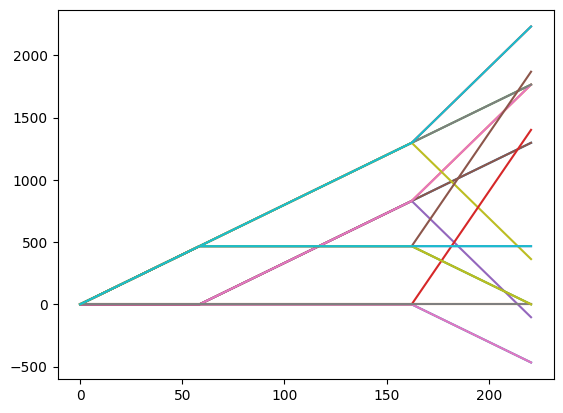

In [2]:
from matplotlib import pyplot as plt

nodes = ifr.get_nodes()
nA, nB, nC, nD = nodes[4*nbragg], nodes[2*nbragg], nodes[0.0*nbragg], nodes[-2*nbragg]
Ts = [0, 0, T, T, T + Tp, T + Tp, T + Tp + T, T + Tp + T]

plt.figure()
for nn in [nA, nB, nC, nD]:
    for p in nn:
        for node in nn[p]:
            t, x = node.get_trajectory()
            plt.plot(t, x)
plt.show()

Create function for simulating the full interferometer

In [3]:
from mwave.integrate import propagate, omega_fnc_gaussian, multi_omega_fnc, phase_fnc_constant
from mwave.precompute import load_precomputed_gbragg
from mwave.utils.cloud import cloud_init

Omega0 = 19.5
w0 = 6.2e-3
sigma = 0.259658916
tau_factor = 5

def deltalookup(vz):
    return 4*nbragg + 4*(vz/0.0035) # The modification to delta is 4 times the velocity defined in units of recoil velocities

def omegalookup(x, y, z):
    return Omega0*np.exp(-2*(x**2 + y**2)/(w0**2))

def make_gbragg(sigma, use_precompute=True, tau_factor=5, tol=1e-8):
    if use_precompute:
        return load_precomputed_gbragg('../precomputation/gbragg_single_sig0.260.h5',
                                       '../precomputation/gbragg_multi_sig0.260.h5',
                                       table_sigma=sigma,
                                       table_modulation_frequency=8*4)

    tfinal = 2*tau_factor*sigma
    t_center = tau_factor*sigma

    def gbragg_fn(kvec, k_init, sigma, omegas, deltas, delta_phase=0.0, mod_freq=None, mod_phase=0.0):
        natoms = len(omegas)
        phi0_batch = np.zeros((natoms, len(kvec)), dtype=np.complex128)
        phi0_batch[:, np.argmin(np.abs(kvec))] = 1.0  # start at k=0 frame

        delta_eff = deltas - 4*k_init  # transform detuning to k=0 frame

        if mod_freq is None:
            result = propagate(
                kvec, phi0_batch, tfinal, delta_eff,
                omega_fnc_gaussian, np.array([1.0, sigma, t_center]),
                phase_fnc_constant, np.array([0.0]),
                omegas=omegas, tol=tol,
            )
        else:
            result = propagate(
                kvec, phi0_batch, tfinal, delta_eff,
                multi_omega_fnc, np.array([1.0, sigma, t_center, mod_freq]),
                phase_fnc_constant, np.array([0.0]),
                omegas=omegas, tol=tol,
            )

        # Apply post-hoc laser phase in k=0 frame (same convention as load_precomputed_gbragg)
        phi = result.phi_final * np.exp(-1j * np.outer(delta_phase, kvec/2))

        # Shift output by Deltan = k_init//2 positions (same as load_precomputed_gbragg)
        Deltan = k_init // 2
        if Deltan == 0:
            return phi
        phi_out = np.zeros_like(phi)
        if Deltan < 0:
            phi_out[:, :Deltan] = phi[:, -Deltan:]
        else:
            phi_out[:, Deltan:] = phi[:, :-Deltan]
        return phi_out

    return gbragg_fn

gbragg = make_gbragg(sigma, use_precompute=True)

def cpops(x0, y0, z0, vz, vx, vy, cphase=0.0, injected_dphase=0.0):
    bs_lookup_dict = {}

    # Define beamsplitter function
    def calc_bs(x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, z, idx):

        # Check if this is a multifrequency beamsplitter
        multifrequency = isinstance(klattice, list)

        # Load cached result
        if idx in bs_lookup_dict:
            if k_init in bs_lookup_dict[idx]:
                if int(k_final) in bs_lookup_dict[idx][k_init]:
                    return bs_lookup_dict[idx][k_init][int(k_final)]

        # Compute omegas and deltas
        x = x0 + vx*t
        y = y0 + vy*t
        omegas = omegalookup(x, y, z0 + z)
        deltas = deltalookup(vz)

        # Set sigma
        sigma = 0.259658916

        # Compute phases
        phases = deltas*t

        # Apply common mode phase if provided and at pulse 3
        if idx == 3:
            phases += cphase

            # Apply differential phase if provided at pulse 3. The way I am injecting this is unphysical/different from how we do in the experiment. But I'm not sure if there is a better way.
            if k_init == 0.0 and k_final == -2.0*nbragg:
                phases += injected_dphase

        # Compute effect of Bragg beamsplitter
        if not multifrequency:
            phi = gbragg(ifr.kvec, int(k_init), sigma, omegas, deltas, delta_phase=phases)
        else:
            phi = gbragg(ifr.kvec, int(k_init), sigma, omegas, deltas, delta_phase=phases, mod_freq=8*4, mod_phase=0.0)

        # Determine index of k_final state
        kf_idx = np.argmin(np.abs(ifr.kvec - k_final))

        # Save wavefunction to cache
        if idx not in bs_lookup_dict:
            bs_lookup_dict[idx] = {}
        if k_init not in bs_lookup_dict[idx]:
            bs_lookup_dict[idx][k_init] = {}
        if int(k_final) not in bs_lookup_dict[idx][k_init]:
            bs_lookup_dict[idx][k_init][int(k_final)] = phi[:,kf_idx]
        else:
            raise RuntimeError('Array should not have been created but it was!')

        # Return
        return phi[:,kf_idx]

    # Define free evolution function
    propfnc = lambda x0, y0, z0, vz, vx, vy, t, k: np.exp(-1j*t*k**2)

    # Apply functions to interferometer
    fnclst = [lambda x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x: calc_bs(x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x, 1),
              propfnc,
              lambda x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x: calc_bs(x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x, 2),
              propfnc,
              lambda x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x: calc_bs(x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x, 3),
              propfnc,
              lambda x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x: calc_bs(x0, y0, z0, vz, vx, vy, k_init, k_final, klattice, t, x, 4)]
    ifr.set_operation_funcs(fnclst)

    # Load population functions
    popfnc = ifr.get_population_func([4*nbragg, 2*nbragg, 0*nbragg, -2*nbragg], lambda x1, x2, x3, x4, x5, x6: np.zeros_like(x0), lambda x1, x2, x3, x4, x5, x6: np.ones_like(x0,dtype=np.complex128), lambda x1, x2, x3, x4, x5, x6: np.zeros_like(x0,dtype=np.complex128))

    # Evaluate populations and return
    return popfnc(4*nbragg, [x0, y0, z0, vz, vx, vy]), popfnc(2*nbragg, [x0, y0, z0, vz, vx, vy]), popfnc(0*nbragg, [x0, y0, z0, vz, vx, vy]), popfnc(-2*nbragg, [x0, y0, z0, vz, vx, vy])

x0, y0, z0, vz, vx, vy = cloud_init(natoms=1000, sigma_cloud=1e-3, sigma_transverse_v=3.5e-3, sigma_vertical_v=0.1*3.5e-3)
pA, pB, pC, pD = cpops(x0, y0, z0, vz, vx, vy, cphase=np.pi/4)


Loading single frequency Bragg precompute table, this could take a while...
Precompute table loaded! Performing checks...
Checks passed!
Loading multifrequency Bragg precompute table, this could take a while...
Precompute table loaded! Performing checks...
Checks passed!


Make ellipse

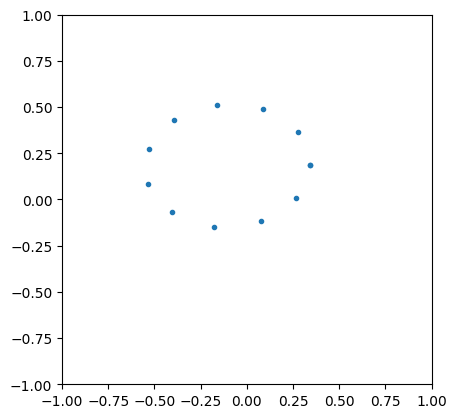

In [4]:
def calc_xy(a, b, c, d):
    return (a-b)/(a+b), (c-d)/(c+d)

x0, y0, z0, vz, vx, vy = cloud_init(natoms=1000, sigma_cloud=1e-3, sigma_transverse_v=0.1*3.5e-3/omega_r_conversion, sigma_vertical_v=0.1*3.5e-3)

cphases = np.linspace(0, 2*np.pi, 12)
x, y = np.full_like(cphases, np.nan), np.full_like(cphases, np.nan)
for i in range(len(cphases)):
    pA, pB, pC, pD = cpops(x0, y0, z0, vz, vx, vy, cphase=cphases[i], injected_dphase=np.pi/8)
    x[i], y[i] = calc_xy(np.sum(pA), np.sum(pB), np.sum(pC), np.sum(pD))

plt.plot(x, y, '.')
plt.gca().set_aspect('equal')
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.show()